In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, f1_score
from sklearn.model_selection import ParameterSampler, StratifiedShuffleSplit
from scipy.stats import randint, uniform

from xgboost import XGBClassifier

In [4]:
df = pd.read_csv('dummy_data/cleaned_data.csv')

In [12]:
df.head()

,subject_id,hadm_id,admission_type,admission_location,insurance,language,marital_status,race,hospital_expire_flag,ccs_seq,...,hour_cos,dow_sin,dow_cos,mon_sin,mon_cos,admission_index,days_since_prev_admission,days_since_first_admission,num_prior_admissions,has_prior_admission
0,10000690,26504700,EW EMER.,EMERGENCY ROOM,Medicare,English,WIDOWED,WHITE,0,"['CIR019', 'CIR019', 'CIR019', 'CIR003', 'CIR0...",...,8.660254e-01,-0.433884,-0.900969,1.224647e-16,-1.000000e+00,0,0.000000,0.000000,0,0
1,10000690,23280645,EW EMER.,EMERGENCY ROOM,Medicare,English,WIDOWED,WHITE,0,"['CIR019', 'CIR019', 'RSP002', 'CIR017', 'END0...",...,2.588190e-01,0.974928,-0.222521,-8.660254e-01,-5.000000e-01,1,71.170833,75.709722,1,1
2,10000690,25860671,EW EMER.,EMERGENCY ROOM,Medicare,English,WIDOWED,WHITE,0,"['RSP010', 'CIR019', 'RSP012', 'RSP012', 'GEN0...",...,-1.836970e-16,0.000000,1.000000,-8.660254e-01,5.000000e-01,2,39.175000,122.636111,2,1
3,10000690,26146595,EW EMER.,EMERGENCY ROOM,Medicare,English,WIDOWED,WHITE,0,"['DIG012', 'DIG012', 'DIG012', 'GEN002', 'CIR0...",...,9.659258e-01,-0.433884,-0.900969,0.000000e+00,1.000000e+00,3,442.413194,574.870833,3,1
4,10001919,29897682,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,Private,English,MARRIED,OTHER,0,"['NEO013', 'NEO070', 'CIR033', 'DIG024', 'XXX0...",...,1.000000e+00,0.433884,-0.900969,1.000000e+00,6.123234e-17,0,0.000000,0.000000,0,0


In [6]:
# ----------------------------
# 1) Custom transformer for MultiLabelBinarizer on one column
#    (assumes missing already encoded as the literal "MISSING")
# ----------------------------
class MLBBinarizer(BaseEstimator, TransformerMixin):
    def __init__(self, missing_literal="MISSING", sep=None):
        self.missing_literal = missing_literal
        self.sep = sep
        self.mlb_ = MultiLabelBinarizer()

    def _row_to_iterable(self, x):
        # If a real NaN slips through, map it to the same literal you used globally
        if pd.isna(x):
            return [self.missing_literal]

        # Already-encoded strings like "MISSING" or "A,B" or "['A','B']"
        if isinstance(x, str):
            s = x.strip()
            if not s:
                return [self.missing_literal]
            # strip simple brackets/quotes
            for ch in ['[', ']', '"', "'"]:
                s = s.replace(ch, '')
            if self.sep is not None:
                parts = [p.strip() for p in s.split(self.sep) if p.strip()]
            else:
                parts = [p.strip() for p in s.split(',') if p.strip()]
                if len(parts) <= 1:
                    parts = [p.strip() for p in s.split() if p.strip()]
            return parts if parts else [self.missing_literal]

        # Lists/tuples/sets already provided
        if isinstance(x, (list, tuple, set)):
            return list(x) if len(x) else [self.missing_literal]

        # Fallback: cast to string and parse
        s = str(x).strip()
        if not s:
            return [self.missing_literal]
        for ch in ['[', ']', '"', "'"]:
            s = s.replace(ch, '')
        parts = [p.strip() for p in s.split(',') if p.strip()]
        if len(parts) <= 1:
            parts = [p.strip() for p in s.split() if p.strip()]
        return parts if parts else [self.missing_literal]

    def fit(self, X, y=None):
        seqs = [self._row_to_iterable(v) for v in np.ravel(X)]
        self.mlb_.fit(seqs)
        return self

    def transform(self, X):
        seqs = [self._row_to_iterable(v) for v in np.ravel(X)]
        return self.mlb_.transform(seqs)

    def get_feature_names_out(self, input_features=None):
        return np.array([f"ccs_{cls}" for cls in self.mlb_.classes_])

In [ ]:
### Mortality Prediction Task (Classification) ###

#Define columns
ID_COLS = ['subject_id', 'hadm_id'] 
TARGET = 'hospital_expire_flag' 

categorical_cols = [ 'admission_type', 'admission_location', 'insurance', 'language', 'marital_status', 'race', 'gender', 'anchor_year_group']

numeric_cols = ['admission_duration', 'ed_duration', 'age_at_admission', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'mon_sin', 'mon_cos', 'admission_index', 'days_since_prev_admission', 'days_since_first_admission', 'num_prior_admissions', 'has_prior_admission', 'ccs_seq_len' ] 

sequence_col = ['ccs_seq'] # single column, but ColumnTransformer expects a list

#mBuild preprocessors
cat_pipe = Pipeline(steps=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

num_pipe = 'passthrough'  # keep as-is

seq_pipe = Pipeline(steps=[
    ('mlb', MLBBinarizer(missing_literal='MISSING'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, categorical_cols),
        ('num', num_pipe, numeric_cols),
        ('seq', seq_pipe, sequence_col),
    ],
    remainder='drop',
    sparse_threshold=0.3
)

# 6) Hyperparameter tuning

# Search space (sane, compact ranges for ~5k pts)
param_distributions = {
    "max_depth": randint(3, 9),              # [3..8]
    "min_child_weight": randint(1, 7),       # [1..6]
    "gamma": uniform(0.0, 2.0),              # [0.0..2.0]
    "subsample": uniform(0.6, 0.4),          # [0.6..1.0]
    "colsample_bytree": uniform(0.6, 0.4),   # [0.6..1.0]
    "reg_lambda": uniform(0.0, 3.0),         # [0.0..3.0]
    "reg_alpha": uniform(0.0, 1.0),          # [0.0..1.0]
    "learning_rate": uniform(0.02, 0.18),    # [0.02..0.20]
    "n_estimators": randint(400, 2201)       # [400..2200] early stopping will clip
}

n_candidates = 30  # increase if you have time
rng = np.random.RandomState(42)
candidates = list(ParameterSampler(param_distributions, n_iter=n_candidates, random_state=rng))

def eval_candidate(params):
    """Train/evaluate one param set across SGKF, return mean AUCPR and extra metrics."""
    fold_pr, fold_roc, fold_f1 = [], [], []
    # new SGKF each candidate keeps splits consistent by using same random_state
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, val_idx in sgkf.split(X, y, groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # fit preprocessor on train only
        prep = clone(preprocessor).fit(X_train)
        X_train_enc = prep.transform(X_train)
        X_val_enc   = prep.transform(X_val)

        # imbalance weight per fold
        pos, neg = (y_train == 1).sum(), (y_train == 0).sum()
        spw = neg / max(pos, 1)

        # model with candidate params + fixed good defaults
        model = XGBClassifier(
            objective='binary:logistic',
            tree_method='hist',
            eval_metric='aucpr',
            early_stopping_rounds=50,
            random_state=42,
            verbosity=0,
            **params
        ).set_params(scale_pos_weight=spw)

        model.fit(X_train_enc, y_train,
                  eval_set=[(X_val_enc, y_val)],
                  verbose=False)

        # validation preds
        val_proba = model.predict_proba(X_val_enc)[:, 1]

        # choose threshold per fold to maximise F1 (optional but usually helps)
        precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)
        # thresholds is len-1 vs precisions/recalls len; handle degenerate cases
        if len(thresholds) > 0:
            f1s = 2 * (precisions[:-1] * recalls[:-1]) / np.clip((precisions[:-1] + recalls[:-1]), 1e-12, None)
            best_th = thresholds[np.argmax(f1s)]
        else:
            best_th = 0.5

        val_pred = (val_proba >= best_th).astype(int)

        fold_pr.append(average_precision_score(y_val, val_proba))
        fold_roc.append(roc_auc_score(y_val, val_proba))
        fold_f1.append(f1_score(y_val, val_pred))

    return {
        "mean_pr": float(np.mean(fold_pr)),
        "std_pr": float(np.std(fold_pr)),
        "mean_roc": float(np.mean(fold_roc)),
        "mean_f1": float(np.mean(fold_f1)),
    }

# run tuning
results = []
best_params, best_score = None, -np.inf

for i, params in enumerate(candidates, 1):
    scores = eval_candidate(params)
    results.append((params, scores))
    if scores["mean_pr"] > best_score:
        best_score = scores["mean_pr"]
        best_params = params
    print(f"[{i}/{n_candidates}] AUCPR={scores['mean_pr']:.4f} (±{scores['std_pr']:.4f}) "
          f"AUC={scores['mean_roc']:.4f} F1={scores['mean_f1']:.4f} | {params}")

print("\nBest params by mean AUCPR:")
print(best_params)
print(f"Best mean AUCPR: {best_score:.4f}")


c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['GEN024', 'INJ050', 'INJ062', 'NVS022', 'PRG009'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['END012', 'INJ063', 'INJ065', 'MBD027', 'NEO005', 'NEO041'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['EYE009', 'FAC020', 'MUS027', 'NEO034', 'NEO036'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['GEN011', 'INJ043', 'INJ061', 'MAL007', 'NEO037', 'NEO059'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserW

[1/30] AUCPR=0.5797 (±0.0663) AUC=0.9648 F1=0.6042 | {'colsample_bytree': np.float64(0.749816047538945), 'gamma': np.float64(1.9014286128198323), 'learning_rate': np.float64(0.1517589095260529), 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 2038, 'reg_alpha': np.float64(0.44583275285359114), 'reg_lambda': np.float64(0.29992474745400866), 'subsample': np.float64(0.7836995567863468)}


c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['GEN024', 'INJ050', 'INJ062', 'NVS022', 'PRG009'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['END012', 'INJ063', 'INJ065', 'MBD027', 'NEO005', 'NEO041'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['EYE009', 'FAC020', 'MUS027', 'NEO034', 'NEO036'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['GEN011', 'INJ043', 'INJ061', 'MAL007', 'NEO037', 'NEO059'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserW

[2/30] AUCPR=0.5915 (±0.0503) AUC=0.9659 F1=0.6080 | {'colsample_bytree': np.float64(0.7334834444556088), 'gamma': np.float64(0.28573363584388156), 'learning_rate': np.float64(0.1371599251307935), 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 743, 'reg_alpha': np.float64(0.8324426408004217), 'reg_lambda': np.float64(0.6370173320348285), 'subsample': np.float64(0.6727299868828402)}


c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['GEN024', 'INJ050', 'INJ062', 'NVS022', 'PRG009'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['END012', 'INJ063', 'INJ065', 'MBD027', 'NEO005', 'NEO041'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['EYE009', 'FAC020', 'MUS027', 'NEO034', 'NEO036'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['GEN011', 'INJ043', 'INJ061', 'MAL007', 'NEO037', 'NEO059'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserW

...

[28/30] AUCPR=0.5940 (±0.0411) AUC=0.9685 F1=0.6009 | {'colsample_bytree': np.float64(0.8607845038010402), 'gamma': np.float64(0.44853861892111957), 'learning_rate': np.float64(0.14819225984255643), 'max_depth': 3, 'min_child_weight': 6, 'n_estimators': 1700, 'reg_alpha': np.float64(0.1788227092213288), 'reg_lambda': np.float64(1.0994063537485799), 'subsample': np.float64(0.8976682092226249)}


c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['GEN024', 'INJ050', 'INJ062', 'NVS022', 'PRG009'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['END012', 'INJ063', 'INJ065', 'MBD027', 'NEO005', 'NEO041'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['EYE009', 'FAC020', 'MUS027', 'NEO034', 'NEO036'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['GEN011', 'INJ043', 'INJ061', 'MAL007', 'NEO037', 'NEO059'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserW

[29/30] AUCPR=0.6062 (±0.0536) AUC=0.9626 F1=0.5854 | {'colsample_bytree': np.float64(0.8883759697008518), 'gamma': np.float64(0.6161215837047784), 'learning_rate': np.float64(0.11765724149988188), 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 869, 'reg_alpha': np.float64(0.26520236768172545), 'reg_lambda': np.float64(0.7319689301372507), 'subsample': np.float64(0.9892042219009782)}


c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['GEN024', 'INJ050', 'INJ062', 'NVS022', 'PRG009'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['END012', 'INJ063', 'INJ065', 'MBD027', 'NEO005', 'NEO041'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['EYE009', 'FAC020', 'MUS027', 'NEO034', 'NEO036'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['GEN011', 'INJ043', 'INJ061', 'MAL007', 'NEO037', 'NEO059'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserW

[30/30] AUCPR=0.6070 (±0.0549) AUC=0.9678 F1=0.5970 | {'colsample_bytree': np.float64(0.7572390898667042), 'gamma': np.float64(1.7840931103542266), 'learning_rate': np.float64(0.1336049526795073), 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 1197, 'reg_alpha': np.float64(0.6451033620305648), 'reg_lambda': np.float64(2.0067721789892987), 'subsample': np.float64(0.9456670260287612)}

Best params by mean AUCPR:
{'colsample_bytree': np.float64(0.6733618039413735), 'gamma': np.float64(0.6084844859190754), 'learning_rate': np.float64(0.11445615769380281), 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 1984, 'reg_alpha': np.float64(0.5247746602583891), 'reg_lambda': np.float64(1.1995829151457664), 'subsample': np.float64(0.6186662652854461)}
Best mean AUCPR: 0.6094


In [26]:
best_params

{'colsample_bytree': np.float64(0.6733618039413735),
 'gamma': np.float64(0.6084844859190754),
 'learning_rate': np.float64(0.11445615769380281),
 'max_depth': 6,
 'min_child_weight': 1,
 'n_estimators': 1984,
 'reg_alpha': np.float64(0.5247746602583891),
 'reg_lambda': np.float64(1.1995829151457664),
 'subsample': np.float64(0.6186662652854461)}

c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['INJ050', 'INJ061', 'MBD027', 'NEO001', 'NVS022', 'PNL010'] will be ignored
  warnings.warn(


AUC-ROC=0.969  AUCPR=0.604  F1@thr=0.596 (thr≈0.659)


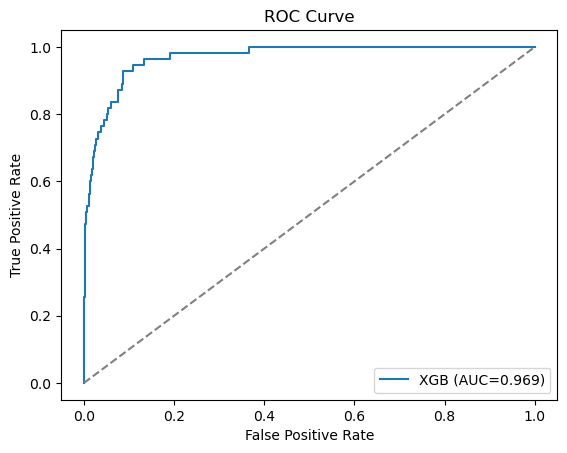

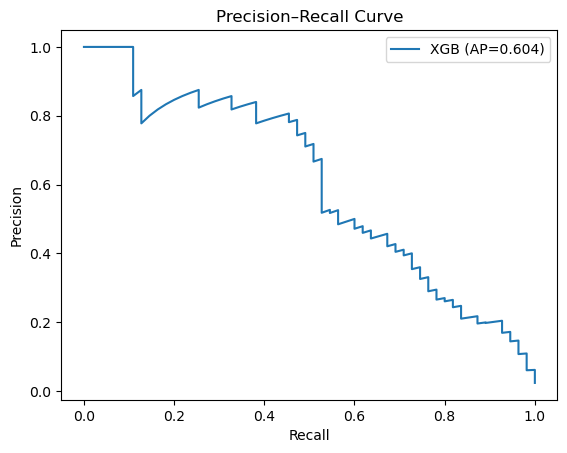

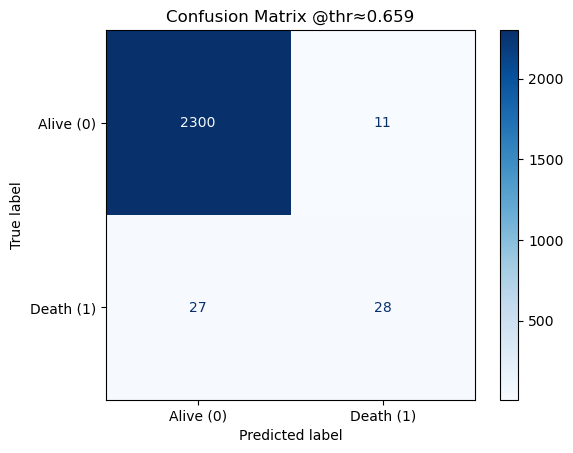

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)

# -------------------------
# 1) Hold-out split
# -------------------------
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, va_idx = next(sss.split(X, y))
X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
y_tr, y_va = y[tr_idx], y[va_idx]

# -------------------------
# 2) Preprocessing
# -------------------------
prep = clone(preprocessor).fit(X_tr)
X_tr_enc = prep.transform(X_tr)
X_va_enc = prep.transform(X_va)

# -------------------------
# 3) Model with tuned params
# -------------------------
pos, neg = (y_tr == 1).sum(), (y_tr == 0).sum()
spw = neg / max(pos, 1)

xgb_best = XGBClassifier(
    objective="binary:logistic",
    tree_method="hist",
    eval_metric="aucpr",
    random_state=42,
    verbosity=0,
    **best_params
).set_params(scale_pos_weight=spw)

xgb_best.fit(X_tr_enc, y_tr, eval_set=[(X_va_enc, y_va)], verbose=False)

# -------------------------
# 4) Probabilities & threshold
# -------------------------
proba = xgb_best.predict_proba(X_va_enc)[:, 1]
auc_roc = roc_auc_score(y_va, proba)
auc_pr  = average_precision_score(y_va, proba)

P, R, T = precision_recall_curve(y_va, proba)
if len(T) > 0:
    f1s = 2 * (P[:-1] * R[:-1]) / np.clip(P[:-1] + R[:-1], 1e-12, None)
    thr = T[np.argmax(f1s)]
else:
    thr = 0.5

pred = (proba >= thr).astype(int)
f1 = f1_score(y_va, pred)

print(f"AUC-ROC={auc_roc:.3f}  AUCPR={auc_pr:.3f}  F1@thr={f1:.3f} (thr≈{thr:.3f})")

# -------------------------
# 5) ROC Curve
# -------------------------
fpr, tpr, _ = roc_curve(y_va, proba)
plt.figure()
plt.plot(fpr, tpr, label=f'XGB (AUC={auc_roc:.3f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# -------------------------
# 6) Precision–Recall Curve
# -------------------------
plt.figure()
plt.plot(R, P, label=f'XGB (AP={auc_pr:.3f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

# -------------------------
# 7) Confusion Matrix
# -------------------------
cm = confusion_matrix(y_va, pred, labels=[0,1])
ConfusionMatrixDisplay(cm, display_labels=["Alive (0)","Death (1)"]).plot(
    values_format="d", cmap="Blues"
)
plt.title(f"Confusion Matrix @thr≈{thr:.3f}")
plt.show()


In [33]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    f1_score, roc_curve
)
from sklearn.base import clone

# -------------------------
# 0) Inputs expected:
#    X: pd.DataFrame of features
#    y: array-like labels
#    groups: array-like group ids (e.g., subject_id) aligned to X/y
#    preprocessor: fitted/fit-able transformer (e.g., ColumnTransformer)
# -------------------------

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []
best = {"aupr": -np.inf, "idx": None}

for fold_idx, (tr_idx, va_idx) in enumerate(sgkf.split(X, y, groups=groups), start=1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    # Fit preprocessing on train only
    prep = clone(preprocessor).fit(X_tr)
    X_tr_enc = prep.transform(X_tr)
    X_va_enc = prep.transform(X_va)

    # RF model (class-imbalance aware)
    rf = RandomForestClassifier(
        n_estimators=1000,
        n_jobs=-1,
        random_state=42,
        class_weight='balanced',
        max_depth=None,
        min_samples_leaf=1
    )
    rf.fit(X_tr_enc, y_tr)

    # Probabilities & metrics
    proba = rf.predict_proba(X_va_enc)[:, 1]
    auc_roc = roc_auc_score(y_va, proba)
    auc_pr  = average_precision_score(y_va, proba)

    # Best-F1 threshold on PR curve
    P, R, T = precision_recall_curve(y_va, proba)
    if len(T) > 0:
        f1s = 2 * (P[:-1] * R[:-1]) / np.clip(P[:-1] + R[:-1], 1e-12, None)
        thr  = T[np.argmax(f1s)]
    else:
        thr = 0.5
    pred = (proba >= thr).astype(int)
    f1   = f1_score(y_va, pred)

    # ROC curve (per fold)
    fpr, tpr, roc_thr = roc_curve(y_va, proba)

    fold_results.append({
        "fold": fold_idx,
        "prep": prep,
        "model": rf,
        "val_idx": va_idx,
        "y_va": y_va,
        "proba": proba,
        "auc_roc": auc_roc,
        "auc_pr": auc_pr,
        "f1": f1,
        "thr_f1": thr,
        "fpr": fpr,
        "tpr": tpr,
        "roc_thr": roc_thr
    })

    print(f"[Fold {fold_idx}] AUC-ROC={auc_roc:.3f}  AUCPR={auc_pr:.3f}  "
          f"F1@thr={f1:.3f} (thr≈{thr:.3f})")

    # Track best model by AUCPR
    if auc_pr > best["aupr"]:
        best.update({"aupr": auc_pr, "idx": fold_idx - 1})

# -------------------------
# Select best model & expose its ROC curve
# -------------------------
best_entry = fold_results[best["idx"]]
best_fpr   = best_entry["fpr"]
best_tpr   = best_entry["tpr"]
best_roc_thresholds = best_entry["roc_thr"]
best_model          = best_entry["model"]
best_preprocessor   = best_entry["prep"]

print("\nBest model by AUCPR:")
print(f"  Fold={best_entry['fold']}  AUCPR={best_entry['auc_pr']:.3f}  "
      f"AUC-ROC={best_entry['auc_roc']:.3f}  F1@thr={best_entry['f1']:.3f}  thr≈{best_entry['thr_f1']:.3f}")

# best_fpr / best_tpr / best_roc_thresholds now contain the FPR/TPR curve for the best model


c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['GEN024', 'INJ050', 'INJ062', 'NVS022', 'PRG009'] will be ignored
  warnings.warn(


[Fold 1] AUC-ROC=0.967  AUCPR=0.509  F1@thr=0.571 (thr≈0.208)


c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['END012', 'INJ063', 'INJ065', 'MBD027', 'NEO005', 'NEO041'] will be ignored
  warnings.warn(


[Fold 2] AUC-ROC=0.977  AUCPR=0.620  F1@thr=0.587 (thr≈0.169)


c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['EYE009', 'FAC020', 'MUS027', 'NEO034', 'NEO036'] will be ignored
  warnings.warn(


[Fold 3] AUC-ROC=0.979  AUCPR=0.539  F1@thr=0.582 (thr≈0.126)


c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['GEN011', 'INJ043', 'INJ061', 'MAL007', 'NEO037', 'NEO059'] will be ignored
  warnings.warn(


[Fold 4] AUC-ROC=0.961  AUCPR=0.574  F1@thr=0.629 (thr≈0.160)


c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['INJ047', 'NEO001', 'NEO049', 'PNL010'] will be ignored
  warnings.warn(


[Fold 5] AUC-ROC=0.971  AUCPR=0.595  F1@thr=0.608 (thr≈0.219)

Best model by AUCPR:
  Fold=2  AUCPR=0.620  AUC-ROC=0.977  F1@thr=0.587  thr≈0.169


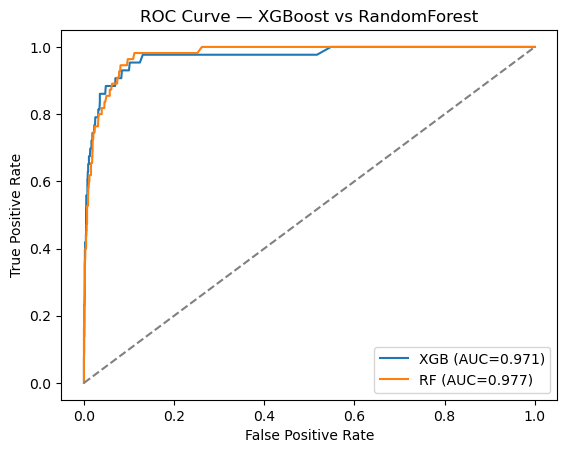

In [38]:
#random forest metrics
best_fpr   = best_entry["fpr"]
best_tpr   = best_entry["tpr"]
best_auc   = best_entry["auc_roc"]

plt.figure()
# XGB curve (from your previous block)
plt.plot(fpr, tpr, label=f'XGB (AUC={auc_roc:.3f})')

# Best RF curve from SGKF CV
plt.plot(best_fpr, best_tpr, 
         label=f'RF (AUC={best_auc:.3f})')

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — XGBoost vs RandomForest")
plt.legend()
plt.show()


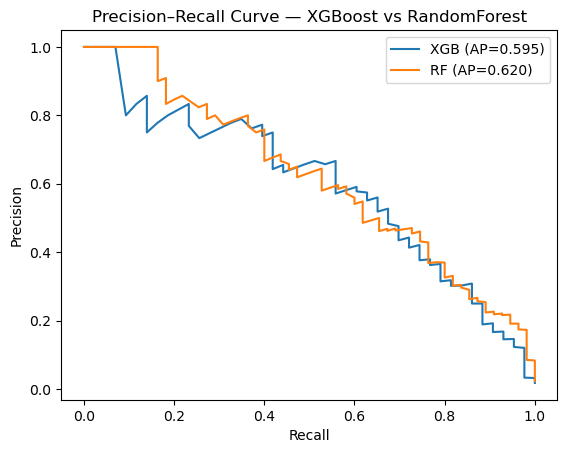

In [39]:
best_P, best_R, _ = precision_recall_curve(best_entry["y_va"], best_entry["proba"])
best_ap = best_entry["auc_pr"]

plt.figure()
# XGB PR curve
plt.plot(R, P, label=f'XGB (AP={auc_pr:.3f})')

# Best RF PR curve
plt.plot(best_R, best_P, 
         label=f'RF (AP={best_ap:.3f})')

plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall Curve — XGBoost vs RandomForest")
plt.legend()
plt.show()


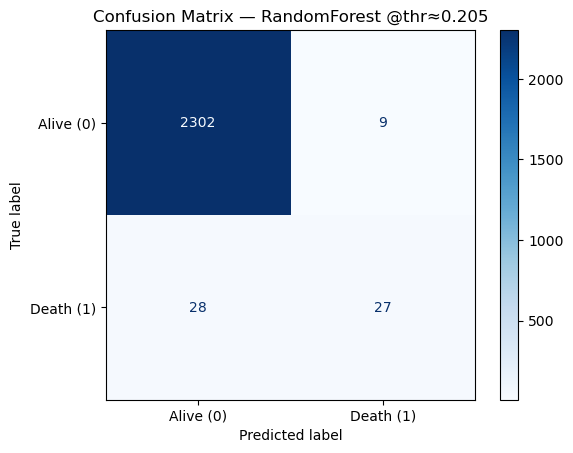

In [32]:
cm_rf = confusion_matrix(y_va, pred_rf, labels=[0,1])
ConfusionMatrixDisplay(cm_rf, display_labels=["Alive (0)","Death (1)"]).plot(
    values_format="d", cmap="Blues"
)
plt.title(f"Confusion Matrix — RandomForest @thr≈{thr_rf:.3f}")
plt.show()


In [11]:
### Prediction of Length of Stay (Regression) ###

id_cols = ["subject_id", "hadm_id"]  # keep but don't use as features

numeric_cols = [
    "age_at_admission", "ed_duration",
    "admit_hour", "admit_weekday", "admit_month",
    "is_weekend", "is_night_admit",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "mon_sin", "mon_cos",
    "admission_index",
    "days_since_prev_admission", "days_since_first_admission",
    "num_prior_admissions", "has_prior_admission",
    "ccs_seq_len",
]
categorical_cols = [
    "gender", "admission_type", "admission_location",
    "insurance", "marital_status", "race",
]

sequence_col = ['ccs_seq'] # single column, but ColumnTransformer expects a list

target_col = "admission_duration"   # your LOS target (assumed in days)
groups = df["subject_id"].values

X = df[numeric_cols + categorical_cols].copy()
y = df[target_col].astype(float).values


In [12]:
cat_pipe = Pipeline(steps=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

num_pipe = 'passthrough'  # keep as-is

seq_pipe = Pipeline(steps=[
    ('mlb', MLBBinarizer(missing_literal='MISSING'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, categorical_cols),
        ('num', num_pipe, numeric_cols),
        ('seq', seq_pipe, sequence_col),
    ],
    remainder='drop',
    sparse_threshold=0.3
)

In [18]:
from sklearn.model_selection import StratifiedGroupKFold
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_los = df[numeric_cols + categorical_cols + sequence_col]
y_los = df["admission_duration"].astype(float).values
groups = df["subject_id"].values

# Create stratification bins (quantiles). Tweak n_bins if needed.
n_bins = 5
los_bins = pd.qcut(y_los, q=n_bins, labels=False, duplicates="drop")

xgb_reg = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1500, learning_rate=0.03, max_depth=6,
    subsample=0.9, colsample_bytree=0.9, tree_method="hist", random_state=42
)

pipe = Pipeline([("prep", preprocessor), ("xgb", xgb_reg)])

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for fold, (tr, va) in enumerate(sgkf.split(X_los, los_bins, groups), 1):
    X_tr, X_va = X_los.iloc[tr], X_los.iloc[va]
    y_tr, y_va = y_los[tr], y_los[va]

    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_va)

    rows.append({
        "fold": fold,
        "MAE": mean_absolute_error(y_va, pred),
        "RMSE": np.sqrt(mean_squared_error(y_va, pred)),
        "R2": r2_score(y_va, pred),
    })

los_cv = pd.DataFrame(rows)
print(los_cv.agg({"MAE":["mean","std"], "RMSE":["mean","std"], "R2":["mean","std"]}))


c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['GEN024', 'INJ065', 'MAL007', 'MBD027', 'NEO005', 'NEO037'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['END012', 'GEN011', 'INJ050', 'INJ062', 'INJ063', 'MUS027', 'NVS022'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['EYE009', 'FAC020', 'INJ074', 'NEO003', 'NEO036'] will be ignored
  warnings.warn(
c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['NEO001', 'NEO049', 'PNL010'] will be ignored
  warnings.warn(


           MAE      RMSE        R2
mean  2.638010  5.585239  0.449941
std   0.166977  0.799246  0.050290


c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['INJ014', 'INJ043', 'INJ047', 'INJ061', 'NEO052', 'NEO067'] will be ignored
  warnings.warn(


In [22]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# True values from your dataset
y_true = y_los

# --- Baseline 1: predict mean LOS ---
y_pred_mean = np.full_like(y_true, fill_value=y_true.mean(), dtype=float)

mae_mean  = mean_absolute_error(y_true, y_pred_mean)
rmse_mean = np.sqrt(mean_squared_error(y_true, y_pred_mean))
r2_mean   = r2_score(y_true, y_pred_mean)

print(f"Mean baseline -> MAE={mae_mean:.2f}, RMSE={rmse_mean:.2f}, R²={r2_mean:.3f}")

# --- Baseline 2: predict median LOS ---
y_pred_median = np.full_like(y_true, fill_value=np.median(y_true), dtype=float)

mae_med  = mean_absolute_error(y_true, y_pred_median)
rmse_med = np.sqrt(mean_squared_error(y_true, y_pred_median))
r2_med   = r2_score(y_true, y_pred_median)

print(f"Median baseline -> MAE={mae_med:.2f}, RMSE={rmse_med:.2f}, R²={r2_med:.3f}")


Mean baseline -> MAE=4.08, RMSE=7.55, R²=0.000
Median baseline -> MAE=3.60, RMSE=7.83, R²=-0.075
